# Optimal creation of entanglement using a two-qubit gate

Authors of [paper](https://link.aps.org/doi/10.1103/PhysRevA.63.062309): B. Kraus and J. I. Cirac (2001)

Author of this notebook: Óscar Amaro (2026)

In this paper, 2 metrics of entropy studied in more depth than the others: the von Neumann entanglement entropy (SvN) and the Rènyi.

**Methods:**
- theory/analytical
- numpy
- qiskit statevector
- qiskit aer

**Structure:**
- imports
- functions
- computing results
- plotting

**Obs:**
- In example 1, a generic product state will not necessarily lead to the maximum SvN. We start with state **|00>**
- In example 2, we are plotting many generic random input states and confirming that the maximum Rènyi entropy for a given alpha is indeed the maximum between the theoretical curves for **me** and **ps**

In [1]:
# numpy pyplot
import numpy as np
np.random.seed(42) # Set seed for reproducible random states
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# scipy
from scipy.linalg import expm
from scipy.optimize import minimize

# qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace, entropy, purity

# Define global font size variable
fontsize = 16

# Define Pauli matrices
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.eye(2, dtype=complex)

# Two-qubit interactions
XX = np.kron(X, X)
YY = np.kron(Y, Y)
ZZ = np.kron(Z, Z)

# U_d acts on A and B. Subsystem order: A (0), A' (1), B (2), B' (3)
# Interaction term: X_A (x) I_A' (x) X_B (x) I_B'
XIXI = np.kron(X, np.kron(I, np.kron(X, I)))


# this defines the domain over which to compute the entropies (theory)
alpha_lst = np.linspace(1e-3,np.pi/4-1e-3,200)
# this defines the domain over which to compute the entropies (numerics)
alpha_vals = np.linspace(0,np.pi/4,20)
# this defines the statistics for the qiskit Aer
NSHOTS = 1000

/var/folders/g9/q9xn_4ss3hs29n0vyt5vnvgw0000gn/T/ipykernel_2939/3638763783.py:12: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


In [6]:
#### Tools

def get_u3(theta, phi, lam=0):
    """General single qubit unitary rotation."""
    return np.array([
        [np.cos(theta/2), -np.exp(1j*lam)*np.sin(theta/2)],
        [np.exp(1j*phi)*np.sin(theta/2), np.exp(1j*(phi+lam))*np.cos(theta/2)]
    ])

def get_unitary(c1, c2, c3):
    """Computes the canonical two-qubit unitary gate."""
    return expm(-1j * (c1 * XX + c2 * YY + c3 * ZZ))
    

# --- 2. State Preparation ---
def make_input_state(params, state_type):
    """Constructs the initial state based on the selected class."""
    ket0 = np.array([1, 0], dtype=complex)
    bell = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
    
    if state_type == 'product':
        psi_A_Aprime = np.kron(ket0, ket0)
        psi_B_Bprime = np.kron(ket0, ket0)
        
    elif state_type == 'max_entangled':
        u_a = get_u3(params[0], params[1])
        u_b = get_u3(params[2], params[3])
        psi_A_Aprime = np.kron(u_a, I) @ bell
        psi_B_Bprime = np.kron(u_b, I) @ bell
        
    elif state_type == 'generic':
        schmidt_A = np.array([np.cos(params[0]), 0, 0, np.sin(params[0])], dtype=complex)
        schmidt_B = np.array([np.cos(params[4]), 0, 0, np.sin(params[4])], dtype=complex)
        u_a = get_u3(params[1], params[2], params[3])
        u_b = get_u3(params[5], params[6], params[7])
        psi_A_Aprime = np.kron(u_a, I) @ schmidt_A
        psi_B_Bprime = np.kron(u_b, I) @ schmidt_B
        
    return np.kron(psi_A_Aprime, psi_B_Bprime)

def get_product_state(theta1, phi1, theta2, phi2):
    """Generates an arbitrary 2-qubit product state using Bloch coordinates."""
    psi1 = np.array([np.cos(theta1 / 2), np.exp(1j * phi1) * np.sin(theta1 / 2)])
    psi2 = np.array([np.cos(theta2 / 2), np.exp(1j * phi2) * np.sin(theta2 / 2)])
    return np.kron(psi1, psi2)

def entropy_of_entanglement(psi_4q):
    """Computes Von Neumann entropy of the A,A' subsystem."""
    psi_tensor = psi_4q.reshape(2, 2, 2, 2)
    # Trace out Bob's system B (axis 2) and B' (axis 3)
    rho_AA = np.tensordot(psi_tensor, psi_tensor.conj(), axes=([2, 3], [2, 3]))
    rho_AA = rho_AA.reshape(4, 4)
    
    # Calculate eigenvalues and entropy
    evals = np.linalg.eigvalsh(rho_AA)
    evals = evals[evals > 1e-12] # Filter zeros to prevent log2(0)
    if len(evals) == 0:
        return 0.0
    return -np.sum(evals * np.log2(evals))

def von_neumann_entropy(state_vector):
    """Computes Von Neumann entropy of the reduced density matrix using SVD."""
    # Reshape 4x1 statevector to a 2x2 matrix for Schmidt decomposition
    schmidt_matrix = state_vector.reshape(2, 2)
    singular_values = np.linalg.svd(schmidt_matrix, compute_uv=False)
    
    # Eigenvalues of the reduced density matrix are the squares of singular values
    probabilities = singular_values**2
    probabilities = probabilities[probabilities > 1e-12] # Avoid log2(0)
    return -np.sum(probabilities * np.log2(probabilities))

def objective_function(params, u_gate):
    """Objective function for minimization (negative von Neumann entropy)."""
    t1, p1, t2, p2 = params
    psi = get_product_state(t1, p1, t2, p2)
    final_state = u_gate @ psi
    return -von_neumann_entropy(final_state)

def find_max_entanglement_numpy(c1, c2=0, c3=0):
    """Finds the maximum entanglement via multi-start optimization."""
    u_gate = get_unitary(c1, c2, c3)
    best_entropy = 0
    best_params = np.zeros(4)
    
    # Run optimization with multiple random initial guesses to avoid local minima
    for _ in range(5):
        x0 = np.random.uniform(0, 2 * np.pi, 4)
        bounds = [(0, np.pi), (0, 2 * np.pi), (0, np.pi), (0, 2 * np.pi)]
        res = minimize(objective_function, x0, args=(u_gate,), bounds=bounds, method='L-BFGS-B')
        if -res.fun > best_entropy:
            best_entropy = -res.fun
            best_params = res.x
            
    return best_entropy, best_params


#### Example 1

def compute_entanglement_qiskit(c1, c2, c3, params):
    """Builds the circuit and calculates entanglement using Qiskit quantum_info."""
    t1, p1, t2, p2 = params
    
    # Initialize a 2-qubit circuit
    qc = QuantumCircuit(2)
    
    # Prepare the optimal initial product state
    qc.ry(t1, 0)
    qc.rz(p1, 0)
    qc.ry(t2, 1)
    qc.rz(p2, 1)
    
    # Apply the non-local canonical Kraus-Cirac interaction gates
    # Factor of 2 accounts for Qiskit's rxx definition: exp(-i * theta/2 * X^X)
    if c1 != 0: qc.rxx(2 * c1, 0, 1)
    if c2 != 0: qc.ryy(2 * c2, 0, 1)
    if c3 != 0: qc.rzz(2 * c3, 0, 1)
    
    # Obtain the Statevector
    sv = Statevector.from_instruction(qc)
    
    # Trace out qubit 1 to get the reduced density matrix of qubit 0
    rho_a = partial_trace(sv, [1])
    
    # Compute Von Neumann entropy (base 2)
    return entropy(rho_a, base=2)


def compute_entanglement_aer_shots(c1, c2, c3, params, num_shots=100):
    """
    Computes entanglement by performing 1-qubit state tomography on Qubit 0
    using a finite number of shots on the AerSimulator.
    """
    t1, p1, t2, p2 = params
    backend = AerSimulator()
    
    # Helper function to generate the base state preparation + interaction circuit
    def build_base_circuit():
        # 2 Qubits, but we only need 1 Classical Bit to record Qubit 0's measurement
        qc = QuantumCircuit(2, 1)
        
        # Prepare the optimal initial product state
        qc.ry(t1, 0)
        qc.rz(p1, 0)
        qc.ry(t2, 1)
        qc.rz(p2, 1)
        
        # Apply the canonical Kraus-Cirac interaction gates
        if c1 != 0: qc.rxx(2 * c1, 0, 1)
        if c2 != 0: qc.ryy(2 * c2, 0, 1)
        if c3 != 0: qc.rzz(2 * c3, 0, 1)
        return qc

    # --- 1. Circuit for Z-basis measurement ---
    qc_z = build_base_circuit()
    qc_z.measure(0, 0)
    
    # --- 2. Circuit for X-basis measurement ---
    # Rotating X-basis to Z-basis using a Hadamard gate
    qc_x = build_base_circuit()
    qc_x.h(0)
    qc_x.measure(0, 0)
    
    # --- 3. Circuit for Y-basis measurement ---
    # Rotating Y-basis to Z-basis using S-dagger and Hadamard gates
    qc_y = build_base_circuit()
    qc_y.sdg(0)
    qc_y.h(0)
    qc_y.measure(0, 0)
    
    # Run all three tomography circuits on the Aer Simulator simultaneously
    job = backend.run([qc_x, qc_y, qc_z], shots=num_shots)
    results = job.result()
    
    # Retrieve the shot count dictionaries
    counts_x = results.get_counts(0)
    counts_y = results.get_counts(1)
    counts_z = results.get_counts(2)
    
    # Helper function to calculate the expectation value ⟨O⟩ = (P_0 - P_1)
    def calculate_expectation(counts):
        n_0 = counts.get('0', 0)
        n_1 = counts.get('1', 0)
        return (n_0 - n_1) / num_shots
    
    # Extract coordinates of the Bloch Vector
    avg_x = calculate_expectation(counts_x)
    avg_y = calculate_expectation(counts_y)
    avg_z = calculate_expectation(counts_z)
    
    # Length of the Bloch vector
    r = np.sqrt(avg_x**2 + avg_y**2 + avg_z**2)
    
    # Due to statistical shot noise fluctuations, r might slightly exceed 1.0
    if r > 1.0:
        r = 1.0
        
    # The eigenvalues of the reconstructed reduced density matrix ρ_A
    lambda_pos = (1 + r) / 2
    lambda_neg = (1 - r) / 2
    
    # Calculate Von Neumann entropy (base 2)
    entropy_val = 0
    if lambda_pos > 1e-12:
        entropy_val -= lambda_pos * np.log2(lambda_pos)
    if lambda_neg > 1e-12:
        entropy_val -= lambda_neg * np.log2(lambda_neg)
        
    return entropy_val

def example1_get_SvN_randstate_numpy(alpha, state_type):
    """Generates a single random state and tracks its entropy over all alphas."""
    num_params = 8 if state_type == 'generic' else 4
    
    # if parameters and the state (params, psi_in) are saved before this line, we see a smooth "trajectory"
    params = np.random.uniform(0, 2 * np.pi, num_params)
    psi_in = make_input_state(params, state_type)
    # Construct Ud for the current alpha
    Ud = np.cos(alpha) * np.eye(16) - 1j * np.sin(alpha) * XIXI
    psi_out = Ud @ psi_in
    return entropy_of_entanglement(psi_out)


#### Example 2

import numpy as np

# --- 1. Pauli Matrix Definitions ---
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# --- 2. Construct Interaction Unitary Ud ---
def example2_get_interaction_unitary(alpha):
    """
    Constructs the 16x16 unitary matrix Ud = exp(-i * alpha * (X_A*X_B + Y_A*Y_B + Z_A*Z_B))
    Subsystem ordering: A(0), A'(1), B(2), B'(3)
    """
    # Create the tensor combinations across the 4 qubits
    XX = np.kron(X, np.kron(I, np.kron(X, I)))
    YY = np.kron(Y, np.kron(I, np.kron(Y, I)))
    ZZ = np.kron(Z, np.kron(I, np.kron(Z, I)))
    
    # Combined exponent matrix
    exponent = -1j * alpha * (XX + YY + ZZ)
    
    # Matrix exponential to compute Ud
    # Using eigh since the exponent is anti-Hermitian (i * Hermitian)
    evals, evecs = np.linalg.eigh(1j * exponent)
    Ud = evecs @ np.diag(np.exp(-1j * evals)) @ evecs.conj().T
    return Ud

# --- 4. Partial Trace & Renyi Calculation ---
def renyi_entropy_example2(psi_in):
    """Computes the Renyi order-2 entropy after applying Ud."""
    
    # Step B: Partial trace over Bob's qubits (subsystems 2 and 3)
    # Reshape to a 4D tensor: (A, A', B, B') where each axis is size 2
    psi_tensor = psi_in.reshape(2, 2, 2, 2)
    
    # Contract/Trace out axes 2 and 3 (Bob) with their complex conjugates
    rho_A = np.tensordot(psi_tensor, psi_tensor.conj(), axes=([2, 3], [2, 3]))
    
    # Flatten Alice's 2x2 remaining indices back into a 4x4 density matrix
    rho_A = rho_A.reshape(4, 4)
    
    # Step C: Compute Purity tr(rho_A^2)
    # Matrix multiplication followed by trace
    purity = np.real(np.trace(rho_A @ rho_A))
    
    # Renyi Entropy = 1 - purity
    return 1.0 - purity


def example2_get_renyi_statevector(alpha, input_type="product"):
    """
    Computes Renyi entanglement using exact Statevector simulation.
    Qubit mapping: 0 -> A, 1 -> A' (Alice), 2 -> B, 3 -> B' (Bob).

    input_type: product |01> or max_entangled |00>+|11>
    """
    qc = QuantumCircuit(4)
    
    # --- State Preparation ---
    if input_type == "product":
        # Product state |01>: Alice is |0>, Bob is |1> (applying X to Bob's primary qubit)
        qc.x(2) 
    elif input_type == "max_entangled":
        # Local maximally entangled states for Alice (0, 1) and Bob (2, 3)
        qc.h(0)
        qc.cx(0, 1)
        qc.h(2)
        qc.cx(2, 3)
    else:
        raise ValueError("input_type must be 'product' or 'max_entangled'")
        
    # --- Apply Unitary U_d on A (0) and B (2) ---
    # The paper uses S_b = sigma_b (x) sigma_b, matching Qiskit's rxx, ryy, rzz
    qc.rxx(2 * alpha, 0, 2)
    qc.ryy(2 * alpha, 0, 2)
    qc.rzz(2 * alpha, 0, 2)
    
    # --- Calculate Renyi Entanglement ---
    sv = Statevector.from_instruction(qc)
    
    # Trace out Bob's qubits (indices 2 and 3)
    rho_alice = partial_trace(sv, [2, 3])
    
    # E_R = 1 - tr(rho_A^2)
    return 1.0 - purity(rho_alice).real

def example2_get_renyi_aer(alpha, input_type="product", num_shots=100):
    """
    Computes Renyi entanglement using the SWAP Test on two copies of the state.
    Qubit Layout (9 qubits total):
      - Copy 1: 0 (A1), 1 (A1'), 2 (B1), 3 (B1')
      - Copy 2: 4 (A2), 5 (A2'), 6 (B2), 7 (B2')
      - Ancilla: 8
    """
    backend = AerSimulator()
    
    # 9 qubits, 1 classical bit for measuring the ancilla
    qc = QuantumCircuit(9, 1)
    
    # --- State Preparation for Both Copies ---
    if input_type == "product":
        # Product state |01>: Alice is |0>, Bob is |1> 
        qc.x(2) # Bob's Qubit B1
        qc.x(6) # Bob's Qubit B2
    elif input_type == "max_entangled":
        # Local maximally entangled states for Copy 1
        qc.h(0); qc.cx(0, 1)
        qc.h(2); qc.cx(2, 3)
        # Local maximally entangled states for Copy 2
        qc.h(4); qc.cx(4, 5)
        qc.h(6); qc.cx(6, 7)
    else:
        raise ValueError("input_type must be 'product' or 'max_entangled'")
        
    # --- Apply Unitary U_d to Both Copies ---
    # Interaction on Copy 1 (A1 and B1)
    qc.rxx(2 * alpha, 0, 2)
    qc.ryy(2 * alpha, 0, 2)
    qc.rzz(2 * alpha, 0, 2)
    
    # Interaction on Copy 2 (A2 and B2)
    qc.rxx(2 * alpha, 4, 6)
    qc.ryy(2 * alpha, 4, 6)
    qc.rzz(2 * alpha, 4, 6)
    
    qc.barrier()
    
    # --- SWAP Test on Alice's Subsystems ---
    # We only apply the controlled-swap to Alice's qubits (A and A'). 
    # Bob's qubits (B and B') are ignored, which physically traces them out.
    qc.h(8)
    
    # Swap A1 with A2
    qc.cswap(8, 0, 4)
    # Swap A1' with A2'
    qc.cswap(8, 1, 5)
    
    qc.h(8)
    
    # Measure the ancilla
    qc.measure(8, 0)
    
    # --- Execution & Expectation Calculation ---
    result = backend.run(qc, shots=num_shots).result()
    counts = result.get_counts()
    
    n_0 = counts.get('0', 0)
    n_1 = counts.get('1', 0)
    
    # The expectation value <Z> of the ancilla gives the purity tr(rho_A^2)
    # <Z> = P(0) - P(1)
    purity_val = (n_0 - n_1) / num_shots
    
    # Clamp to handle minor statistical shot noise exceeding theoretical bounds
    purity_val = min(max(purity_val, 0.0), 1.0)
    
    # E_R = 1 - tr(rho_A^2)
    return 1.0 - purity_val


def example2_get_renyi_randstate_numpy(alpha):
    """Generates a single random state and tracks its entropy over all alphas."""
    num_params = 8 
    
    # if parameters and the state (params, psi_in) are saved before this line, we see a smooth "trajectory"
    params = np.random.uniform(0, 2 * np.pi, num_params)
    psi_in = make_input_state(params, state_type="generic")
    # Construct Ud for the current alpha
    Ud = example2_get_interaction_unitary(alpha)
    psi_out = Ud @ psi_in
    
    return renyi_entropy_example2(psi_out)

In [21]:
### Example 1 - compute results
# Generate data for Figure 1 (c2 = 0, c3 = 0)
example1_maxSvN_numpy_lst = []
optimal_parameters = []
for alpha in alpha_vals:
    entropy_val, params = find_max_entanglement_numpy(alpha, c2=0, c3=0)
    example1_maxSvN_numpy_lst.append(entropy_val)
    optimal_parameters.append(params)

# Verify against Qiskit using the optimal parameters found
example1_SvN_statevector_lst = []
for alpha, params in zip(alpha_vals, optimal_parameters):
    ent_qiskit = compute_entanglement_qiskit(alpha, 0, 0, params)
    example1_SvN_statevector_lst.append(ent_qiskit)

# Choose a standard shot configuration (e.g., 1024 for visible noise, 8192 for clean convergence)
example1_SvN_aer_lst = []
# Using c1_vals and optimal_parameters from the original NumPy optimization step
for alpha, params in zip(alpha_vals, optimal_parameters):
    ent_measurement = compute_entanglement_aer_shots(alpha, 0, 0, params, num_shots=NSHOTS)
    example1_SvN_aer_lst.append(ent_measurement)

#
example1_SvN_randstate_numpy_lst = []
for ii in range(20):
    tmp = []
    for i in range(len(alpha_vals)):
        tmp.append( example1_get_SvN_randstate_numpy(alpha_vals[i],'generic') )
    example1_SvN_randstate_numpy_lst.append(tmp)
#
example1_SvN_me_numpy_lst = []
for ii in range(4):
    tmp = []
    for i in range(len(alpha_vals)):
        tmp.append( example1_get_SvN_randstate_numpy(alpha_vals[i],'max_entangled') )
    example1_SvN_me_numpy_lst.append(tmp)
#
example1_SvN_ps_numpy_lst = []
for i in range(len(alpha_vals)):
    example1_SvN_ps_numpy_lst.append( example1_get_SvN_randstate_numpy(alpha_vals[i],'product') )



### Example 2 - compute results
# Example 2 - compute results
example2_renyi_statevector_ps_lst = np.array([example2_get_renyi_statevector(alpha, input_type="product") for alpha in alpha_vals])
example2_renyi_statevector_me_lst = np.array([example2_get_renyi_statevector(alpha, input_type="max_entangled") for alpha in alpha_vals])
#
example2_renyi_aer_ps_lst = np.array([example2_get_renyi_aer(alpha, input_type="product", num_shots=NSHOTS) for alpha in alpha_vals])
example2_renyi_aer_me_lst = np.array([example2_get_renyi_aer(alpha, input_type="max_entangled", num_shots=NSHOTS) for alpha in alpha_vals])

# adjust statistics if necessary
example2_renyi_randstate_numpy_lst = []
for ii in range(5000):
    tmp = []
    for i in range(len(alpha_vals)):
        tmp.append( example2_get_renyi_randstate_numpy(alpha_vals[i]) )
    example2_renyi_randstate_numpy_lst.append(tmp)

# Example 1

/var/folders/g9/q9xn_4ss3hs29n0vyt5vnvgw0000gn/T/ipykernel_2939/1698045359.py:22: RuntimeWarning: divide by zero encountered in log2
  maxEE_theory = -np.cos(alpha_lst)**2 * np.log2(np.cos(alpha_lst)**2) -np.sin(alpha_lst)**2 * np.log2(np.sin(alpha_lst)**2)
/var/folders/g9/q9xn_4ss3hs29n0vyt5vnvgw0000gn/T/ipykernel_2939/1698045359.py:22: RuntimeWarning: invalid value encountered in multiply
  maxEE_theory = -np.cos(alpha_lst)**2 * np.log2(np.cos(alpha_lst)**2) -np.sin(alpha_lst)**2 * np.log2(np.sin(alpha_lst)**2)


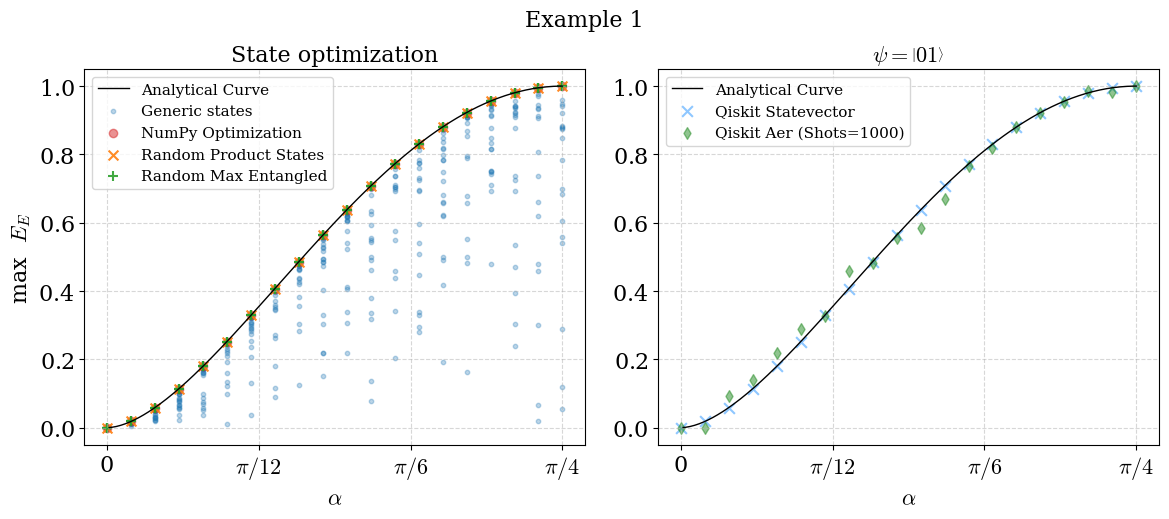

In [32]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",     # Force Computer Modern fontset for all math text
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize
})
#
# Force LaTeX font styling on X and Y axis tick marks
for i in range(2):
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))  # Forces scientific notation
    axes[i].xaxis.set_major_formatter(formatter)
    axes[i].yaxis.set_major_formatter(formatter)

# Example 1
# Analytical theoretical curve from Kraus & Cirac (2001)
# this expression looks similar to sin^2 but is less symmetric
maxEE_theory = -np.cos(alpha_lst)**2 * np.log2(np.cos(alpha_lst)**2) -np.sin(alpha_lst)**2 * np.log2(np.sin(alpha_lst)**2)
#
alpha_marker = 0.5
for i in range(2):
    axes[i].plot(alpha_lst, maxEE_theory, label='Analytical Curve', color='black', linewidth=1)
#axes[0].plot(c1_vals, theoretical_entropies, label='Analytical Curve', color='black', linewidth=1)

# Plot 10 Random Generic States
for i in range(len(example1_SvN_randstate_numpy_lst)):
    axes[0].scatter(alpha_vals, np.array(example1_SvN_randstate_numpy_lst[i]), s=10, color='tab:blue', alpha=0.3, linewidth=1, label="Generic states" if i==0 else "")

# Numpy optimization 
axes[0].scatter(alpha_vals, example1_maxSvN_numpy_lst, label='NumPy Optimization', color='tab:red', marker='o', alpha=0.5)

#
# Plot |00> product state
axes[0].scatter(alpha_vals, example1_SvN_ps_numpy_lst, alpha=0.9, s=50, marker='x', color='tab:orange', label='Random Product States' )
#
# Plot 4 Random Max Entangled States
for i in range(len(example1_SvN_me_numpy_lst)):
    axes[0].scatter(alpha_vals, np.array(example1_SvN_me_numpy_lst[i]), s=50, marker='+', alpha=0.9, color='tab:green', label='Random Max Entangled' if i==0 else "")



# |01>
axes[1].scatter(alpha_vals, example1_SvN_statevector_lst, label='Qiskit Statevector', color='dodgerblue', marker='x', s=60, alpha=alpha_marker)
axes[1].scatter(alpha_vals, example1_SvN_aer_lst, label=f'Qiskit Aer (Shots={NSHOTS})', color='forestgreen', marker='d', alpha=alpha_marker)


plt.suptitle(r'Example 1', fontsize=fontsize)
axes[0].set_ylabel(r'max  $E_E$')
axes[0].set_title(r'State optimization', fontsize=fontsize)
axes[1].set_title(r'$\psi=\left| 01 \right\rangle$', fontsize=fontsize)
axes[0].legend(fontsize=11)
axes[1].legend(fontsize=11)
#
for i in range(2):
    axes[i].set_xlabel(r'$\alpha$')
    axes[i].set_xticks([0, np.pi/12, np.pi/6, np.pi/4], ['0', r'$\pi/12$', r'$\pi/6$', r'$\pi/4$'])
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_ylim([0-0.05,1.0+0.05])

# aspect ratio
for i in range(2):
    xmin, xmax = axes[i].get_xlim()
    ymin, ymax = axes[i].get_ylim()
    axesratio = (ymax-ymin)/(xmax-xmin)
    #axesratio = (np.log10(ymax)-np.log10(ymin))/(xmax-xmin)
    axes[i].set_aspect(aspect=3/4/axesratio)
#
plt.tight_layout()
#plt.savefig('example1_fig0.png',transparent=True)
plt.show()

# Example 2

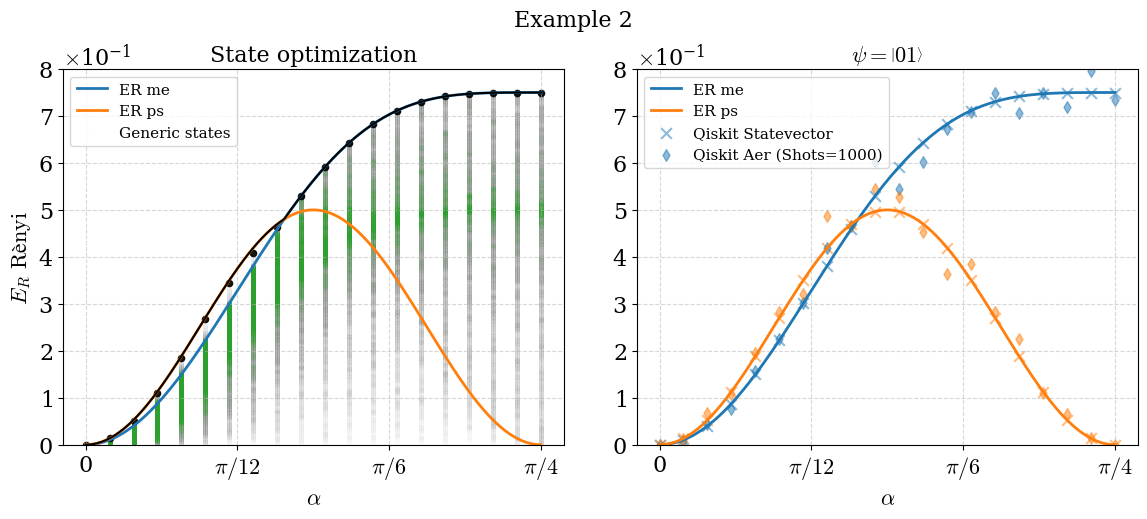

In [31]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",     # Force Computer Modern fontset for all math text
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize
})
#
# Force LaTeX font styling on X and Y axis tick marks
for i in range(2):
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))  # Forces scientific notation
    axes[i].xaxis.set_major_formatter(formatter)
    axes[i].yaxis.set_major_formatter(formatter)


# Example 2
alpha_lst = np.linspace(0,np.pi/4,200)
# theory
ER_me_theory = 3/16 * (3 - 2*np.cos(4*alpha_lst) - np.cos(4*alpha_lst)**2 )
ER_ps_theory = 1/2 * (1 - np.cos(4*alpha_lst)**2 )
#
for i in range(2):
    axes[i].plot(alpha_lst, ER_me_theory, label='ER me', linewidth=2)
    axes[i].plot(alpha_lst, ER_ps_theory, label='ER ps', linewidth=2)

# qiskit statevector
axes[1].scatter( alpha_vals, example2_renyi_statevector_me_lst, label='Qiskit Statevector', color='tab:blue', marker='x', s=60, alpha=alpha_marker)
axes[1].scatter( alpha_vals, example2_renyi_statevector_ps_lst,  color='tab:orange', marker='x', s=60, alpha=alpha_marker)

# Plot 10 Random Generic States
for i in range(len(example2_renyi_randstate_numpy_lst)):
    axes[0].scatter(alpha_vals, np.array(example2_renyi_randstate_numpy_lst[i]), s=10, color='tab:green', alpha=0.1/50, linewidth=1, label="Generic states" if i==0 else "")
# plot max(ms,pe)
axes[0].plot(alpha_lst, np.array([np.max(max(ER_me_theory[i], ER_ps_theory[i]) ) for i in range(len(alpha_lst))]), 'k-' )
for i in range(len(alpha_vals)):
    axes[0].scatter(alpha_vals[i], np.max( np.array(example2_renyi_randstate_numpy_lst)[:,i] ), s=20, color='k', alpha=0.9 )

# qiskit aer
axes[1].scatter(alpha_vals, example2_renyi_aer_me_lst, label=f'Qiskit Aer (Shots={NSHOTS})', color='tab:blue', marker='d', alpha=alpha_marker)
axes[1].scatter(alpha_vals, example2_renyi_aer_ps_lst, color='tab:orange', marker='d', alpha=alpha_marker)


plt.suptitle(r'Example 2', fontsize=fontsize)
axes[0].set_ylabel(r'$E_R~\mathrm{Rènyi}$')
axes[0].set_title(r'State optimization', fontsize=fontsize)
axes[1].set_title(r'$\psi=\left| 01 \right\rangle$', fontsize=fontsize)
axes[0].legend(fontsize=11)
axes[1].legend(fontsize=11)
#
for i in range(2):
    axes[i].set_xlabel(r'$\alpha$')
    axes[i].set_xticks([0, np.pi/12, np.pi/6, np.pi/4], ['0', r'$\pi/12$', r'$\pi/6$', r'$\pi/4$'])
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_ylim([0,0.8])
#
# aspect ratio
for i in range(2):
    xmin, xmax = axes[i].get_xlim()
    ymin, ymax = axes[i].get_ylim()
    axesratio = (ymax-ymin)/(xmax-xmin)
    #axesratio = (np.log10(ymax)-np.log10(ymin))/(xmax-xmin)
    axes[i].set_aspect(aspect=3/4/axesratio)
#
plt.tight_layout()
#plt.savefig('example2_fig1.png',transparent=True)
plt.show()